Loading Preprocessed Data and Model Inputs

The analysis begins by loading the prepared inputs required for anomaly detection. The processed transaction dataset is read from a structured storage location to provide identifiers and contextual fields (e.g., addresses, timestamps, transaction metadata) required for downstream merging and interpretation. In parallel, the scaled numerical feature matrix is loaded from a serialized NumPy array file (X_scaled.npy), ensuring that the Isolation Forest model operates on the exact standardized representation produced during preprocessing.

To preserve transparency and reproducibility, the list of numerical feature names is loaded from an external text file (feature_names.txt). This enables consistent feature alignment between preprocessing and modeling and supports interpretability when analyzing anomaly behavior across individual variables. A shape consistency check is then applied to confirm that the number of feature columns in the scaled matrix matches the number of recorded feature names, preventing silent misalignment errors. Finally, basic dataset dimensions are printed to verify successful loading and to document the model input size.

In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

# Load cleaned data (for IDs and later merging)
df = pd.read_csv("../data/processed/uniswap_v3_usdc_weth_swaps_processed.csv")

# Load scaled features (for model input)
X_scaled = np.load("../data/processed/X_scaled.npy")

# Load feature names (optional, for interpretation)
with open("../data/processed/feature_names.txt") as f:
    numeric_features = [line.strip() for line in f]

assert X_scaled.shape[1] == len(numeric_features)

print("Data shape:", X_scaled.shape)
print("Number of features:", len(numeric_features))


Data shape: (1000, 7)
Number of features: 7


Application of Isolation Forest for Transaction Anomaly Detection

Isolation Forest is an unsupervised anomaly detection algorithm that identifies outliers by recursively partitioning the feature space using randomly selected features and split values. Transactions that can be isolated with fewer partitions are considered anomalous, as they deviate more strongly from the dominant data distribution. This approach does not rely on distributional assumptions and is well suited for high-dimensional and irregular transaction data.

In this implementation, the model is applied directly to the scaled numerical feature matrix generated during preprocessing, ensuring consistent input representation across all transactions. The Isolation Forest is configured with 200 estimators to enhance stability and reduce variance in anomaly detection outcomes. The contamination parameter is set to 0.05, indicating the expected proportion of anomalous transactions and defining the decision threshold used by the model. A fixed random state is used to ensure reproducibility.

After training, the model assigns a binary anomaly label to each transaction, where 1 denotes normal behavior and -1 denotes anomalous behavior. These labels are appended to the processed transaction dataset, allowing anomaly predictions to be directly linked to the corresponding transaction records for subsequent analysis and interpretation.

In [9]:
from sklearn.ensemble import IsolationForest

# Select scaled features for anomaly detection
scaled_features = [f"{col}_scaled" for col in numeric_features]
X_scaled_for_if = X_scaled

# Build and fit the Isolation Forest model
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # assume ~5% anomalies
    random_state=42
)

iso_labels = iso_model.fit_predict(X_scaled_for_if)

# Add anomaly labels back into dataset
df["isolation_forest_anomaly"] = iso_labels


Separation of Normal and Anomalous Transactions

Following the assignment of Isolation Forest anomaly labels, the transaction dataset is partitioned into two subsets based on the predicted classification. Transactions labeled as anomalous (-1) are extracted into an anomaly subset, while transactions labeled as normal (1) are retained in a separate subset.

The number of transactions in each category is then reported to provide a quantitative overview of the model output and to verify consistency with the expected anomaly proportion. This separation enables focused analysis of anomalous behavior and supports subsequent comparative, statistical, and interpretability-driven analyses.

In [10]:
anomalies = df[df["isolation_forest_anomaly"] == -1]
normal = df[df["isolation_forest_anomaly"] == 1]

print("Anomaly count:", len(anomalies))
print("Normal count:", len(normal))


Anomaly count: 50
Normal count: 950


Feature-Level Comparison Between Normal and Anomalous Transactions

To support interpretation of the anomaly detection results, the scaled feature matrix is converted into a structured DataFrame aligned with the original transaction indices. This representation enables direct association between scaled numerical values and the corresponding transactions classified by the Isolation Forest model.

Using the anomaly labels, the scaled feature data is partitioned into normal and anomalous subsets. For each numerical feature, the mean value is then computed separately for normal and anomalous transactions. These aggregated statistics are presented side by side to facilitate direct comparison of typical feature behavior across the two groups.

This feature-level comparison highlights systematic differences between normal and anomalous transactions in the standardized feature space. Observed deviations provide insight into which transaction characteristics contribute most strongly to anomalous classifications and support a clearer understanding of the behavioral patterns identified by the Isolation Forest model.

In [11]:
# Build scaled DataFrame for interpretation
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=numeric_features,
    index=df.index
)

# Split normal vs anomaly
normal_scaled = X_scaled_df[df["isolation_forest_anomaly"] == 1]
anomalies_scaled = X_scaled_df[df["isolation_forest_anomaly"] == -1]

# Compare feature means
feature_means = pd.DataFrame({
    "Normal Mean": normal_scaled.mean(),
    "Anomaly Mean": anomalies_scaled.mean()
})

feature_means



,Normal Mean,Anomaly Mean
amount0,0.005136,-26.647223
amount1,-0.003886,26.680018
sqrtPriceX96,-0.276475,-0.601545
liquidity,15.342616,1550.200562
tick,-0.271649,-0.601333
gasPrice,1.232260,12.792939
gasUsed,0.283071,5.001079


Identification of Frequently Occurring Addresses in Anomalous Transactions

To further analyze anomalous activity at the address level, the frequency of sender and recipient addresses within the anomalous transaction subset is examined. The most frequently occurring sender and recipient addresses are identified by computing occurrence counts and selecting the top entries.

This analysis helps reveal whether anomalous transactions are associated with a small number of repeatedly active addresses or are more uniformly distributed across participants. Concentrated occurrence of specific addresses within the anomalous subset may indicate automated behavior, coordinated activity, or entities that consistently engage in atypical transaction patterns. Such insights complement transaction-level anomaly detection by introducing an entity-centric perspective.

In [12]:
top_anomaly_senders = anomalies["sender"].value_counts().head(5)
top_anomaly_recipients = anomalies["recipient"].value_counts().head(5)

top_anomaly_senders, top_anomaly_recipients


(sender
 0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad    17
 0xe8cfad4c75a5e1caf939fd80afcf837dde340a69    14
 0xe592427a0aece92de3edee1f18e0157c05861564     7
 0xdef1c0ded9bec7f1a1670819833240f027b25eff     3
 0x51c72848c68a965f66fa7a88855f9f7784502a7f     2
 Name: count, dtype: int64,
 recipient
 0xe8cfad4c75a5e1caf939fd80afcf837dde340a69    14
 0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad    11
 0x638a98bbb92a7582d07c52ff407d49664dc8b3ee     3
 0xdef171fe48cf0115b1d80b88dc8eab59176fee57     3
 0x51c72848c68a965f66fa7a88855f9f7784502a7f     2
 Name: count, dtype: int64)

Visualization of Anomalous Transactions in the Scaled Feature Space

To visually assess the separation between normal and anomalous transactions, a two-dimensional scatter plot is constructed using the scaled values of amount0 and amount1. These features represent the exchanged token quantities in swap transactions and are central to characterizing transaction magnitude and direction.

Normal and anomalous transactions are plotted separately with differing transparency levels, enabling clear visual distinction while preserving the overall distribution structure. The use of scaled values ensures that the visualization reflects relative deviations rather than raw magnitude differences, which may otherwise dominate the plot due to extreme values.

This visualization provides an intuitive illustration of how anomalous transactions diverge from typical behavior in the feature space. Anomalies tend to appear at the extremes or along sparsely populated regions of the distribution, supporting the Isolation Forest model’s identification of transactions that deviate significantly from common swap patterns. The plot thus serves as a qualitative validation of the anomaly detection results and complements the quantitative analyses presented earlier.

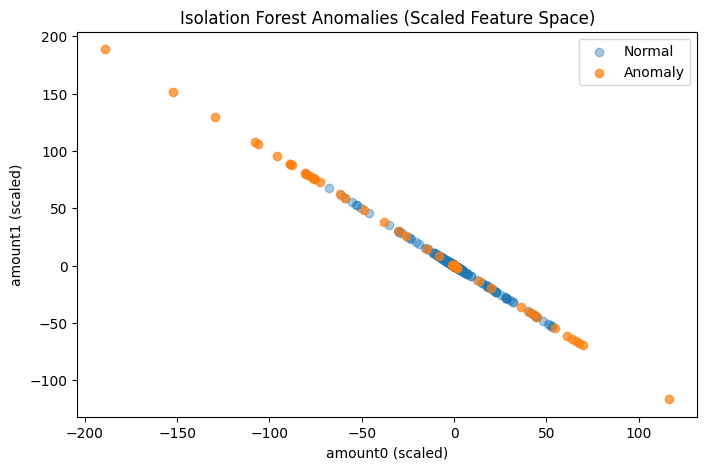

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.scatter(
    normal_scaled["amount0"],
    normal_scaled["amount1"],
    alpha=0.4,
    label="Normal"
)

plt.scatter(
    anomalies_scaled["amount0"],
    anomalies_scaled["amount1"],
    alpha=0.7,
    label="Anomaly"
)

plt.xlabel("amount0 (scaled)")
plt.ylabel("amount1 (scaled)")
plt.legend()
plt.title("Isolation Forest Anomalies (Scaled Feature Space)")
plt.show()



Temporal Analysis of Isolation Forest–Detected Anomalies

To examine how anomalous activity evolves over time, the timestamps associated with anomalous transactions are converted into a standardized datetime format and used as a temporal index. The anomalous transactions are then aggregated using hourly resampling, producing a time series that represents the number of detected anomalies within each hour.

This temporal aggregation enables analysis of the distribution and concentration of anomalous transactions across time. By visualizing the hourly anomaly counts, it becomes possible to identify periods of increased anomalous activity, as well as intervals of relative stability. Such temporal patterns may reflect shifts in market conditions, bursts of automated or coordinated behavior, or short-lived events that trigger atypical transaction dynamics.

The resulting time-series visualization provides a complementary perspective to feature-based analyses by highlighting when anomalous behavior occurs, thereby supporting a more comprehensive understanding of the temporal structure of anomalies identified by the Isolation Forest model.

C:\Users\aycag\AppData\Local\Temp\ipykernel_16152\885130669.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies["timeStamp_dt"] = pd.to_datetime(anomalies["timeStamp_dt"])


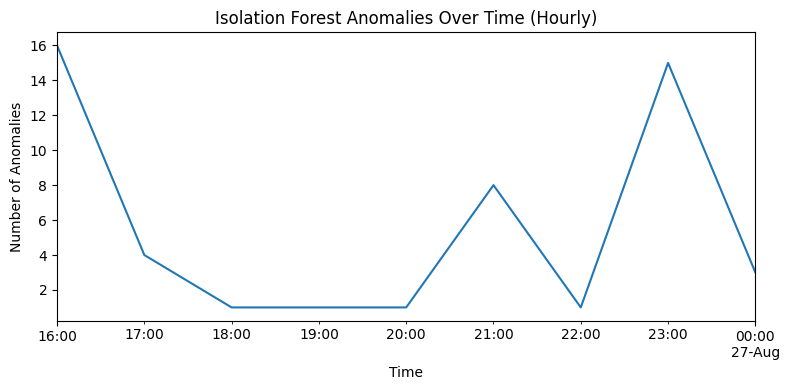

In [22]:
# Ensure datetime index
anomalies["timeStamp_dt"] = pd.to_datetime(anomalies["timeStamp_dt"])

anomalies_per_hour = (
    anomalies
    .set_index("timeStamp_dt")
    .resample("h")
    .size()
)

plt.figure(figsize=(8, 4))
anomalies_per_hour.plot()
plt.title("Isolation Forest Anomalies Over Time (Hourly)")
plt.ylabel("Number of Anomalies")
plt.xlabel("Time")
plt.tight_layout()
plt.show()



Computation and Interpretation of Isolation Forest Anomaly Scores

In addition to producing binary anomaly labels, the Isolation Forest model provides a continuous anomaly score for each transaction through its decision function. This score reflects the relative degree to which a transaction deviates from typical behavior, based on how easily it is isolated within the ensemble of isolation trees.

The raw output of the decision function is sign-inverted so that higher values correspond to a higher level of anomalous behavior. The resulting values are stored in the dataset as isolation_score, enabling transactions to be ranked according to anomaly severity rather than evaluated solely through binary classification.

A descriptive statistical summary of the anomaly scores is then generated to examine their distribution and range across the dataset. This summary provides insight into the spread and concentration of anomaly intensities and supports subsequent analytical steps that focus on identifying and interpreting the most extreme anomalous transactions detected by the Isolation Forest model.

In [15]:
# Isolation Forest anomaly scores (higher = more anomalous after sign flip)
anomaly_scores = iso_model.decision_function(X_scaled_for_if)

df["isolation_score"] = -anomaly_scores  # flip so larger = more anomalous

print("Isolation Forest anomaly score summary:\n")
print(df["isolation_score"].describe())


Isolation Forest anomaly score summary:

count    1000.000000
mean       -0.165725
std         0.068196
min        -0.224304
25%        -0.207184
50%        -0.186941
75%        -0.163931
max         0.200054
Name: isolation_score, dtype: float64


Identification of Transactions with the Highest Anomaly Scores

To facilitate focused inspection of the most extreme anomalous behaviors, transactions are ranked according to their Isolation Forest anomaly scores. The transactions with the highest scores—indicating the greatest deviation from typical transaction patterns—are selected for closer examination.

For each of the top-ranked anomalous transactions, key attributes such as sender and recipient addresses, transferred token amounts, liquidity levels, gas price, and the corresponding anomaly score are presented. This targeted overview enables direct linkage between high anomaly scores and concrete transaction characteristics, supporting interpretability and providing a practical basis for identifying transactions that may warrant deeper investigation.

In [16]:
print("\nTop 5 highest-risk anomalies:\n")
cols_to_show = ["sender", "recipient", "amount0", "amount1", "liquidity", "gasPrice", "isolation_score"]
print(df.sort_values("isolation_score", ascending=False).head(5)[cols_to_show])


Top 5 highest-risk anomalies:

                                         sender  \
16   0xe8cfad4c75a5e1caf939fd80afcf837dde340a69   
31   0xe8cfad4c75a5e1caf939fd80afcf837dde340a69   
901  0x3208684f96458c540eb08f6f01b9e9afb2b7d4f0   
889  0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad   
819  0xe8cfad4c75a5e1caf939fd80afcf837dde340a69   

                                      recipient       amount0  \
16   0xe8cfad4c75a5e1caf939fd80afcf837dde340a69 -421800456347   
31   0xe8cfad4c75a5e1caf939fd80afcf837dde340a69 -523931437876   
901  0x3208684f96458c540eb08f6f01b9e9afb2b7d4f0 -265430999843   
889  0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad -222018850285   
819  0xe8cfad4c75a5e1caf939fd80afcf837dde340a69 -358847328580   

                   amount1               liquidity      gasPrice  \
16   255828679014122873255    42650691009184698025  0x38e5e5d377   
31   318093935332575067681    36436129027849465614  0x97c6c186fc   
901  161460000000000000000   834267773667859163307   0x2a05c99b7  

Clustering of Anomalous Transactions Based on Scaled Feature Similarity

To further analyze heterogeneity within the anomalous transaction set, a clustering procedure is applied exclusively to transactions classified as anomalous by the Isolation Forest model. The scaled numerical feature representation is used as input to ensure that clustering is based on standardized transaction characteristics and is not influenced by differences in feature magnitude.

A KMeans clustering algorithm with two clusters is employed to partition anomalous transactions into distinct subgroups according to feature similarity. This unsupervised clustering aims to uncover potential structure within the anomalous subset, revealing whether anomalies can be grouped into multiple behavioral patterns rather than forming a single homogeneous class. A fixed random state is specified to ensure reproducibility of the clustering results.

The resulting cluster assignments are stored as anomaly_group, and the distribution of transactions across clusters is examined to assess cluster composition and balance. This step enhances interpretability by enabling differentiation between multiple types of anomalous behavior and supports more granular analysis of anomaly characteristics within the detected outlier set.

In [17]:
from sklearn.cluster import KMeans

# Use scaled features for anomaly clustering
anom_scaled = X_scaled_df[df["isolation_forest_anomaly"] == -1]


kmeans = KMeans(n_clusters=2, random_state=42)
anom_scaled["anomaly_group"] = kmeans.fit_predict(anom_scaled)


# Optional: see how many in each group
anom_scaled["anomaly_group"].value_counts()


C:\Users\aycag\AppData\Local\Temp\ipykernel_16152\2309953026.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anom_scaled["anomaly_group"] = kmeans.fit_predict(anom_scaled)


anomaly_group
1    39
0    11
Name: count, dtype: int64

Characterization of Anomalous Transaction Clusters

Following the clustering of anomalous transactions, the scaled numerical features are aggregated by anomaly cluster to compute cluster-level mean values. These aggregated statistics form representative profiles that summarize the typical characteristics of each anomaly group identified by the clustering process.

By comparing the mean feature values across clusters, this analysis highlights systematic differences in transaction behavior among distinct subsets of anomalies. Such differences may reflect varying transaction magnitudes, liquidity conditions, or execution patterns associated with different types of anomalous activity. The resulting cluster profiles provide a concise and interpretable summary of how anomalous behaviors diverge within the outlier population, supporting deeper analytical insight beyond binary anomaly classification.

In [18]:
cluster_profiles = anom_scaled.groupby("anomaly_group").mean()
cluster_profiles


,amount0,amount1,sqrtPriceX96,liquidity,tick,gasPrice,gasUsed
anomaly_group,,,,,,,
0,-42.266502,42.347505,-0.016700,6471.036980,-0.006061,-0.369953,1.306436
1,-22.241785,22.260983,-0.766502,162.272342,-0.769231,16.505550,6.043158


Visualization of Feature-Level Differences Across Anomalous Clusters

To further interpret the structure of anomalous transaction clusters, box plots are generated for each scaled numerical feature, grouped by anomaly cluster membership. These visualizations illustrate the distribution, central tendency, and variability of each feature within the identified anomaly groups.

By comparing feature distributions across clusters, the box plots highlight which transaction attributes exhibit the most pronounced differences between anomalous subgroups. Such differences may indicate distinct behavioral patterns, transaction magnitudes, or execution characteristics within the broader anomalous population. This visual analysis complements the cluster-level statistical summaries and supports a more nuanced understanding of heterogeneous anomalous behaviors detected by the Isolation Forest model.

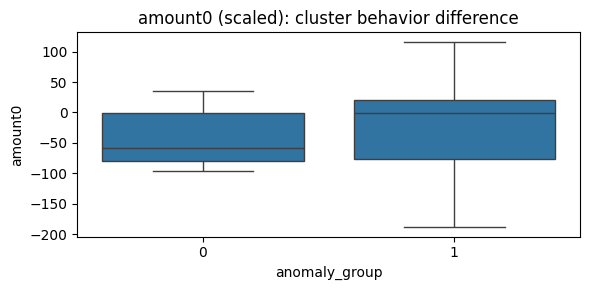

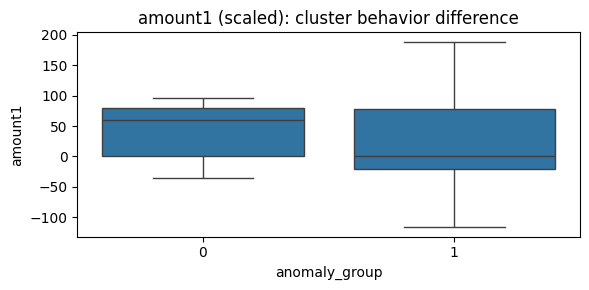

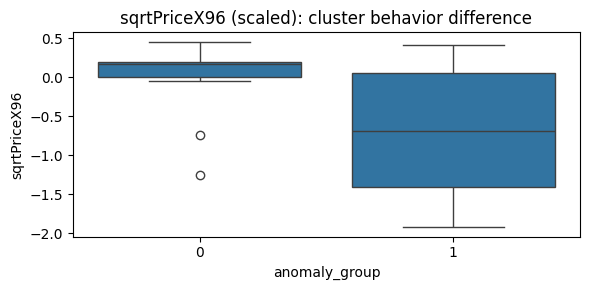

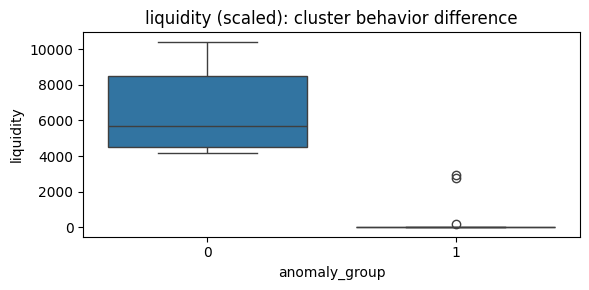

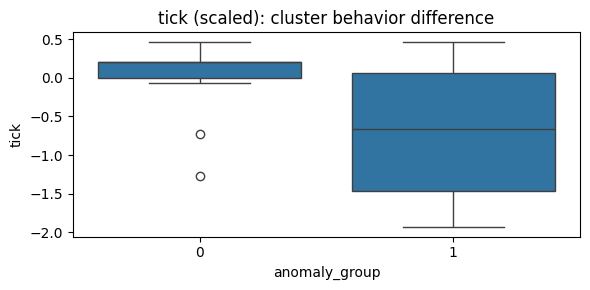

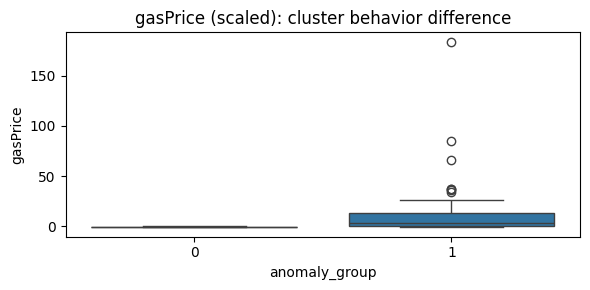

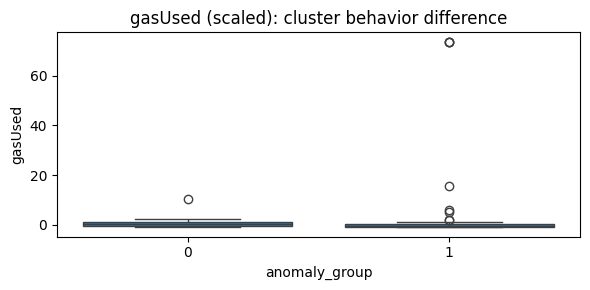

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numeric_features:
    plt.figure(figsize=(6, 3))
    sns.boxplot(
        data=anom_scaled,
        x="anomaly_group",
        y=col
    )
    plt.title(f"{col} (scaled): cluster behavior difference")
    plt.tight_layout()
    plt.show()


Dimensionality Reduction and Visualization of Anomaly Separation Using PCA

To provide a low-dimensional representation of transaction behavior and facilitate visual inspection of anomaly separation, Principal Component Analysis (PCA) is applied to the scaled numerical feature matrix. PCA is a linear dimensionality reduction technique that projects high-dimensional data onto a set of orthogonal components that capture the maximum variance present in the original feature space.

In this analysis, the first two principal components are extracted and stored as PC1 and PC2, forming a two-dimensional embedding of transaction behavior. The resulting PCA coordinates are aligned with the original transaction indices and augmented with the Isolation Forest anomaly labels to preserve the association between each transaction and its anomaly classification.

A scatter plot of the two principal components is then generated, with normal and anomalous transactions visually distinguished. This visualization enables qualitative assessment of how anomalous transactions are positioned relative to normal transactions in the reduced feature space. Observable separation, clustering, or dispersion patterns provide insight into the structural differences captured by the anomaly detection model and support interpretability of the Isolation Forest results by illustrating how anomalous behavior manifests across the dominant variance directions in the data.

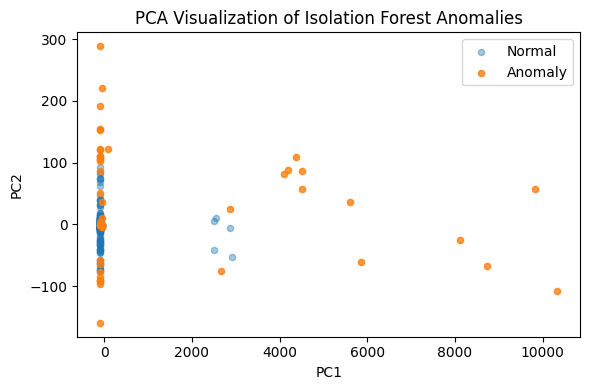

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# PCA on scaled features
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(X_scaled)

# Store PCA results in DataFrame
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"],
    index=df.index
)

# Attach anomaly labels
pca_df["isolation_forest_anomaly"] = df["isolation_forest_anomaly"]

# Plot
plt.figure(figsize=(6, 4))

plt.scatter(
    pca_df[pca_df["isolation_forest_anomaly"] == 1]["PC1"],
    pca_df[pca_df["isolation_forest_anomaly"] == 1]["PC2"],
    s=20, alpha=0.4, label="Normal"
)

plt.scatter(
    pca_df[pca_df["isolation_forest_anomaly"] == -1]["PC1"],
    pca_df[pca_df["isolation_forest_anomaly"] == -1]["PC2"],
    s=20, alpha=0.8, label="Anomaly"
)

plt.legend()
plt.title("PCA Visualization of Isolation Forest Anomalies")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


Persistence of Isolation Forest Outputs for Downstream Analysis

The final step of the Isolation Forest pipeline focuses on persisting key model outputs to structured files in order to support reproducibility, downstream modeling, and result inspection outside the execution environment.

First, the primary Isolation Forest results are saved, including the unique transaction identifier, the binary anomaly label, and the continuous anomaly score for each transaction. Storing these outputs enables independent analysis of anomaly predictions and facilitates integration with reporting, visualization, or external validation workflows.

Second, the indices of transactions classified as normal are extracted and saved separately. These indices serve as a filtered reference set for subsequent modeling stages, such as training an autoencoder on predominantly normal transaction behavior. Persisting this information ensures that the same subset of data can be reused consistently without recomputing anomaly labels.

Finally, when available, cluster assignments for anomalous transactions are saved alongside their corresponding transaction identifiers. This optional output preserves the finer-grained grouping of anomalous behavior identified during clustering and enables further examination of anomaly subtypes or targeted investigation of specific anomaly groups.

Collectively, these saved artifacts establish a clear interface between the Isolation Forest component and subsequent analytical stages, while ensuring traceability, reproducibility, and modularity within the overall anomaly detection pipeline.

In [21]:
# =========================
# SAVE ISOLATION FOREST RESULTS
# =========================

# 1) Save main Isolation Forest results
if_results = df[[
    "transactionHash",
    "isolation_forest_anomaly",
    "isolation_score"
]]

if_results.to_csv(
    "../results/isolation_forest_results.csv",
    index=False
)

print("Saved: isolation_forest_results.csv")


# 2) Save indices of NORMAL data for Autoencoder
normal_indices = df.index[df["isolation_forest_anomaly"] == 1].to_numpy()

np.save(
    "../results/if_normal_indices.npy",
    normal_indices
)

print(f"Saved normal indices for Autoencoder: {len(normal_indices)} samples")


# 3) (Optional) Save anomaly cluster labels
if "anomaly_group" in anom_scaled.columns:
    anomaly_groups_df = df.loc[
        df["isolation_forest_anomaly"] == -1,
        ["transactionHash"]
    ].copy()

    anomaly_groups_df["anomaly_group"] = anom_scaled["anomaly_group"].values

    anomaly_groups_df.to_csv(
        "../results/if_anomaly_clusters.csv",
        index=False
    )

    print("Saved: if_anomaly_clusters.csv")


Saved: isolation_forest_results.csv
Saved normal indices for Autoencoder: 950 samples
Saved: if_anomaly_clusters.csv
